# Template genérico — Treinamento de modelo + Interpretabilidade (SHAP & AME)

Este notebook é uma versão generalizada de um pipeline de classificação binária com
diagnóstico de interpretabilidade combinando três métodos:

1. **Feature importance nativa** de um modelo de árvore (impureza / Gini).
2. **SHAP** — contribuição de cada feature para a predição de um modelo de árvore.
3. **AME (Average Marginal Effects)** — efeito médio de cada variável na probabilidade
   prevista, a partir de uma Regressão Logística (statsmodels).
4. **Ranking consolidado** comparando os três métodos.

**Como usar:** edite apenas a célula de **Configuração** (seção 0) e o dicionário de
**modelos** (seção 5) para adaptar a outro dataset/problema. O resto do notebook foi
escrito para funcionar sem alterações adicionais, desde que:
- o problema seja de **classificação binária** (target 0/1);
- exista pelo menos um modelo baseado em árvore **sem PCA** no pipeline (para o SHAP);
- exista uma **Regressão Logística** no pipeline (para o AME).


## 0. Configuração

Edite apenas esta célula para adaptar o notebook a outro dataset/modelo.

In [4]:
# ============================================================
# CONFIGURAÇÃO — edite aqui para adaptar a outro projeto
# ============================================================

CONFIG = {

    # Caminho do arquivo de dados (CSV)
    "data_path": "abt_churn.csv",

    # Coluna alvo (variável a ser prevista) — precisa ser binária (0/1)
    "target_column": "target",

    # Coluna de identificador único (ex.: ID do cliente). Não entra como feature.
    # Deixe None se não existir.
    "id_column": None,  # ex: "idCliente"

    # Colunas que vazam informação do target (proxies do próprio evento, ou
    # calculadas com dados posteriores ao período de referência) e por isso
    # devem ser removidas das features X. Inclua o próprio target_column aqui.
    "leakage_columns": [
        "target",
        # "coluna_suspeita_1",
        # "coluna_suspeita_2",
    ],

    # Limiar de correlação (|r|) com o target acima do qual uma coluna que NÃO
    # está em leakage_columns é sinalizada como suspeita de vazamento.
    "leakage_corr_threshold": 0.7,

    # Coluna de data/tempo para split temporal (treino = período mais antigo,
    # teste = período mais recente). Deixe None para usar split aleatório.
    "time_column": None,  # ex: "dtRef"

    # Fração aproximada dos dados usada como teste
    "test_size": 0.25,

    # Nome do modelo (chave do dicionário MODELS, seção 5) usado no SHAP.
    # Precisa ser um modelo baseado em árvore e SEM PCA no pipeline.
    "shap_tree_model": "Gradient Boosting",

    # Nome do modelo (chave do dicionário MODELS, seção 5) usado no AME.
    # Precisa ser uma Regressão Logística.
    "ame_logit_model": "Logistic Regression",

    # Semente aleatória para reprodutibilidade
    "random_state": 42,

    # Quantas features mostrar nos rankings/gráficos (SHAP, AME, importância)
    "top_n_features": 15,
}


## 1. Imports

In [5]:
# Manipulação e tratamento dos dados
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Train/test split e pré-processamento
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.decomposition import PCA
from sklearn.base import clone

# Modelos
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC

# Métricas
from sklearn.metrics import (
    accuracy_score, classification_report, confusion_matrix,
    roc_curve, roc_auc_score
)

np.random.seed(CONFIG["random_state"])


## 2. Carregamento dos dados

In [6]:
df_original = pd.read_csv(CONFIG["data_path"])
df_original.shape


(5496, 43)

## 3. Exploração dos dados (EDA)

Primeiras e últimas linhas do dataset.

In [7]:
df_original.head()

,dtRef,idUsuario,qtdeTransacoes,qtdeDias,mediaTransacoesDias,saldoPontos,qtdePontosPos,qtdePontosNeg,qtdeDiasUltimaTransacao,qtdeDiasPrimeiraTransacao,...,saldoPontosD28,qtdePontosPosD28,qtdePontosNegD28,propAvgQtdeTransacoes,propAvgQtdeDias,propAvgMediaTransacoesDias,propAvgSaldoPontos,propAvgQtdePontosPos,propAvgQtdePontosNeg,flagChurn
0,2024-06-01,000ff655-fa9f-4baa-a108-47f581ec52a1,266,27,9.851852,635,2635,-2000,1.0,89.0,...,151,151,0,3.889781,3.278281,2.135602,1.516314,4.101926,8.944444,1
1,2024-10-01,000ff655-fa9f-4baa-a108-47f581ec52a1,268,28,9.571429,686,2686,-2000,4.0,211.0,...,51,51,0,3.309865,2.567615,2.328737,1.288278,2.920954,5.167037,1
2,2024-04-01,000ff655-fa9f-4baa-a108-47f581ec52a1,188,11,17.090909,275,1275,-1000,3.0,28.0,...,275,1275,-1000,3.805468,1.820201,3.739048,0.798622,2.634551,7.162791,0
3,2024-05-01,000ff655-fa9f-4baa-a108-47f581ec52a1,262,24,10.916667,484,2484,-2000,2.0,58.0,...,107,1107,-1000,4.246216,3.255244,2.322640,1.275749,4.275765,9.922414,0
4,2024-08-01,001749bd-37b5-4b1e-8111-f9fbba90f530,1,1,1.000000,50,50,0,21.0,21.0,...,50,50,0,0.013317,0.103973,0.236635,0.104533,0.063302,0.000000,1


In [8]:
df_original.tail()

,dtRef,idUsuario,qtdeTransacoes,qtdeDias,mediaTransacoesDias,saldoPontos,qtdePontosPos,qtdePontosNeg,qtdeDiasUltimaTransacao,qtdeDiasPrimeiraTransacao,...,saldoPontosD28,qtdePontosPosD28,qtdePontosNegD28,propAvgQtdeTransacoes,propAvgQtdeDias,propAvgMediaTransacoesDias,propAvgSaldoPontos,propAvgQtdePontosPos,propAvgQtdePontosNeg,flagChurn
5491,2025-02-01,ff07d926-f09e-420b-bebf-3dba02ae5dff,3,1,3.0,52,52,0,11.0,11.0,...,52,52,0,0.036148,0.085733,0.744779,0.098768,0.053507,0.0,0
5492,2025-03-01,ff07d926-f09e-420b-bebf-3dba02ae5dff,5,2,2.5,54,54,0,1.0,39.0,...,2,2,0,0.061868,0.173459,0.626703,0.104061,0.057551,0.0,1
5493,2024-06-01,ff1ceaef-650c-422b-bdc3-6984e29e7aa5,15,3,5.0,162,162,0,17.0,19.0,...,162,162,0,0.219349,0.364253,1.083858,0.386839,0.252187,0.0,1
5494,2025-03-01,ff2cabd3-3316-4b3f-8494-c25f95e90524,8,1,8.0,57,57,0,19.0,19.0,...,57,57,0,0.098988,0.086730,2.005448,0.109843,0.060749,0.0,1
5495,2024-06-01,ff4909ad-4e52-4767-a6fc-0fbd76e37857,1,1,1.0,50,50,0,24.0,24.0,...,50,50,0,0.014623,0.121418,0.216772,0.119395,0.077835,0.0,1


Tipos de dados e contagem de valores não nulos de cada coluna.

In [9]:
df_original.info()

<class 'pandas.DataFrame'>
RangeIndex: 5496 entries, 0 to 5495
Data columns (total 43 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   dtRef                       5496 non-null   str    
 1   idUsuario                   5496 non-null   str    
 2   qtdeTransacoes              5496 non-null   int64  
 3   qtdeDias                    5496 non-null   int64  
 4   mediaTransacoesDias         5496 non-null   float64
 5   saldoPontos                 5496 non-null   int64  
 6   qtdePontosPos               5496 non-null   int64  
 7   qtdePontosNeg               5496 non-null   int64  
 8   qtdeDiasUltimaTransacao     5496 non-null   float64
 9   qtdeDiasPrimeiraTransacao   5496 non-null   float64
 10  qtdSkuDistintos             5496 non-null   int64  
 11  qtdeChatMessage             5496 non-null   int64  
 12  qtdePresença                5496 non-null   int64  
 13  qtdeTrocaStreamElements     5496 non-null   

Percentual de valores ausentes em cada coluna.

In [10]:
(df_original.isnull().sum() * 100 / len(df_original)).sort_values(ascending=False)

dtRef                         0.0
idUsuario                     0.0
qtdeTransacoes                0.0
qtdeDias                      0.0
mediaTransacoesDias           0.0
saldoPontos                   0.0
qtdePontosPos                 0.0
qtdePontosNeg                 0.0
qtdeDiasUltimaTransacao       0.0
qtdeDiasPrimeiraTransacao     0.0
qtdSkuDistintos               0.0
qtdeChatMessage               0.0
qtdePresença                  0.0
qtdeTrocaStreamElements       0.0
qtdeChurn                     0.0
qtdePonei                     0.0
qtdeAirflowLover              0.0
qtdePresencaStreak            0.0
qtdeDailyLoot                 0.0
qtdeRLover                    0.0
qtdeVendaItemRPG              0.0
qtdeTransacoesD7              0.0
qtdeDiasD7                    0.0
saldoPontosD7                 0.0
qtdePontosPosD7               0.0
qtdePontosNegD7               0.0
qtdeTransacoesD14             0.0
qtdeDiasD14                   0.0
saldoPontosD14                0.0
qtdePontosPosD

Total de linhas duplicadas.

In [11]:
df_original.duplicated().sum()

np.int64(0)

Quantidade de valores únicos por coluna.

In [12]:
df_original.nunique()

dtRef                           14
idUsuario                     2251
qtdeTransacoes                 759
qtdeDias                       217
mediaTransacoesDias           1941
saldoPontos                   1956
qtdePontosPos                 2270
qtdePontosNeg                  151
qtdeDiasUltimaTransacao         27
qtdeDiasPrimeiraTransacao      377
qtdSkuDistintos                 16
qtdeChatMessage                682
qtdePresença                   200
qtdeTrocaStreamElements         40
qtdeChurn                      106
qtdePonei                       34
qtdeAirflowLover                10
qtdePresencaStreak              42
qtdeDailyLoot                   27
qtdeRLover                       6
qtdeVendaItemRPG                19
qtdeTransacoesD7               152
qtdeDiasD7                       8
saldoPontosD7                  561
qtdePontosPosD7                504
qtdePontosNegD7                 16
qtdeTransacoesD14              209
qtdeDiasD14                     15
saldoPontosD14      

Boxplot de cada variável numérica (exclui a coluna de ID, se houver), para visualizar outliers.

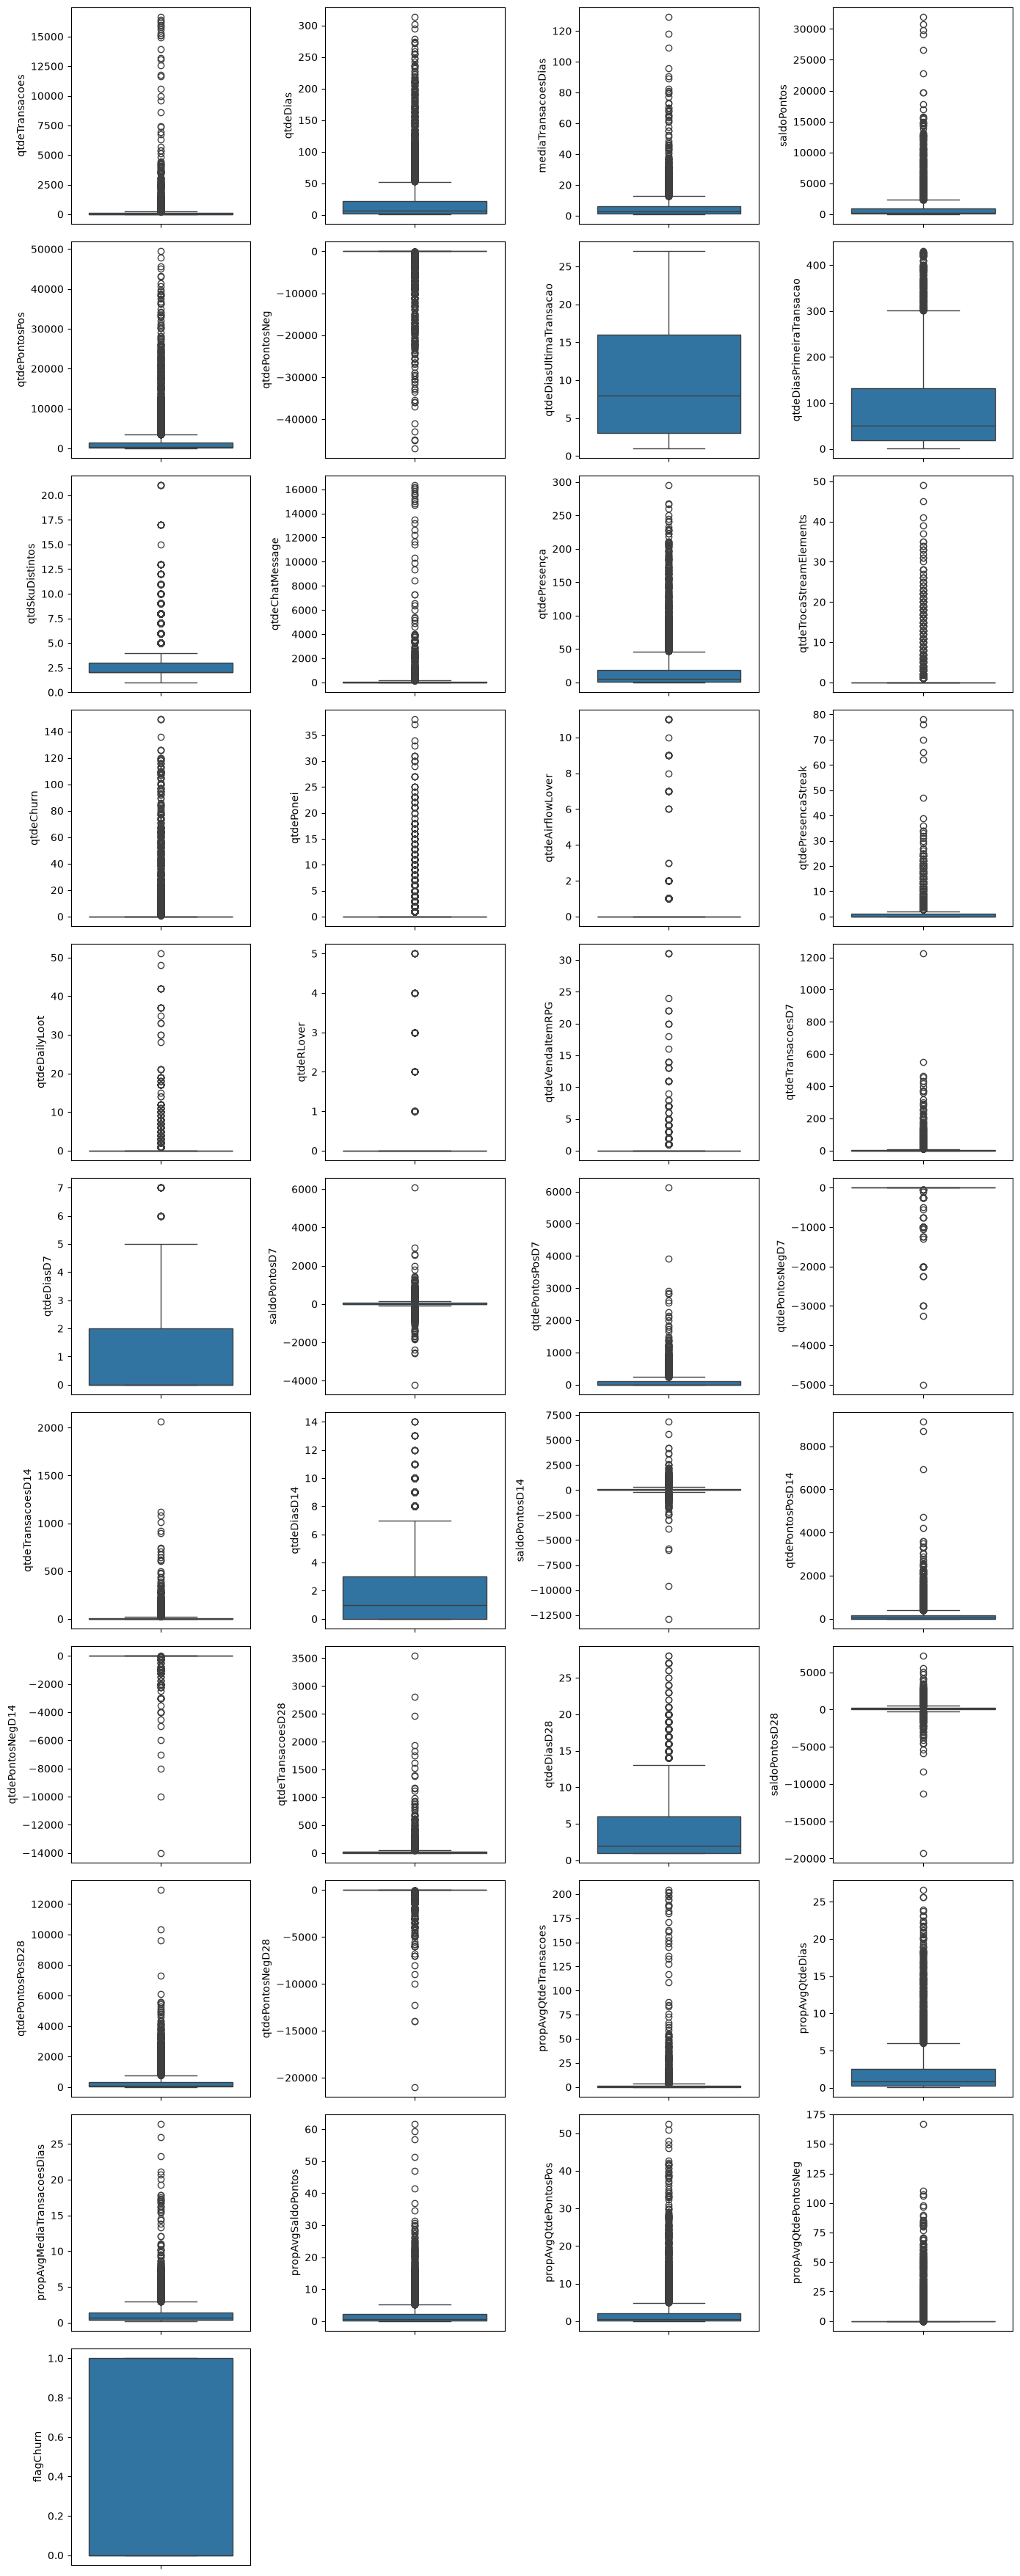

In [13]:
cols_para_boxplot = [
    c for c in df_original.columns
    if c != CONFIG["id_column"]
    and df_original[c].dtype in ("int64", "float64")
]

n_cols = 4
n_linhas = int(np.ceil(len(cols_para_boxplot) / n_cols))

plt.rcParams["figure.figsize"] = [14.00, 3.2 * n_linhas]
plt.rcParams["figure.autolayout"] = True
f, axes = plt.subplots(n_linhas, n_cols, squeeze=False)

linha, coluna = 0, 0
for c in cols_para_boxplot:
    sns.boxplot(data=df_original, y=c, ax=axes[linha][coluna])
    coluna += 1
    if coluna == n_cols:
        linha += 1
        coluna = 0

# Remove eixos vazios sobrando na última linha
for j in range(coluna, n_cols):
    if linha < n_linhas:
        f.delaxes(axes[linha][j])

plt.show()


Mapa de calor de correlação entre as variáveis numéricas.

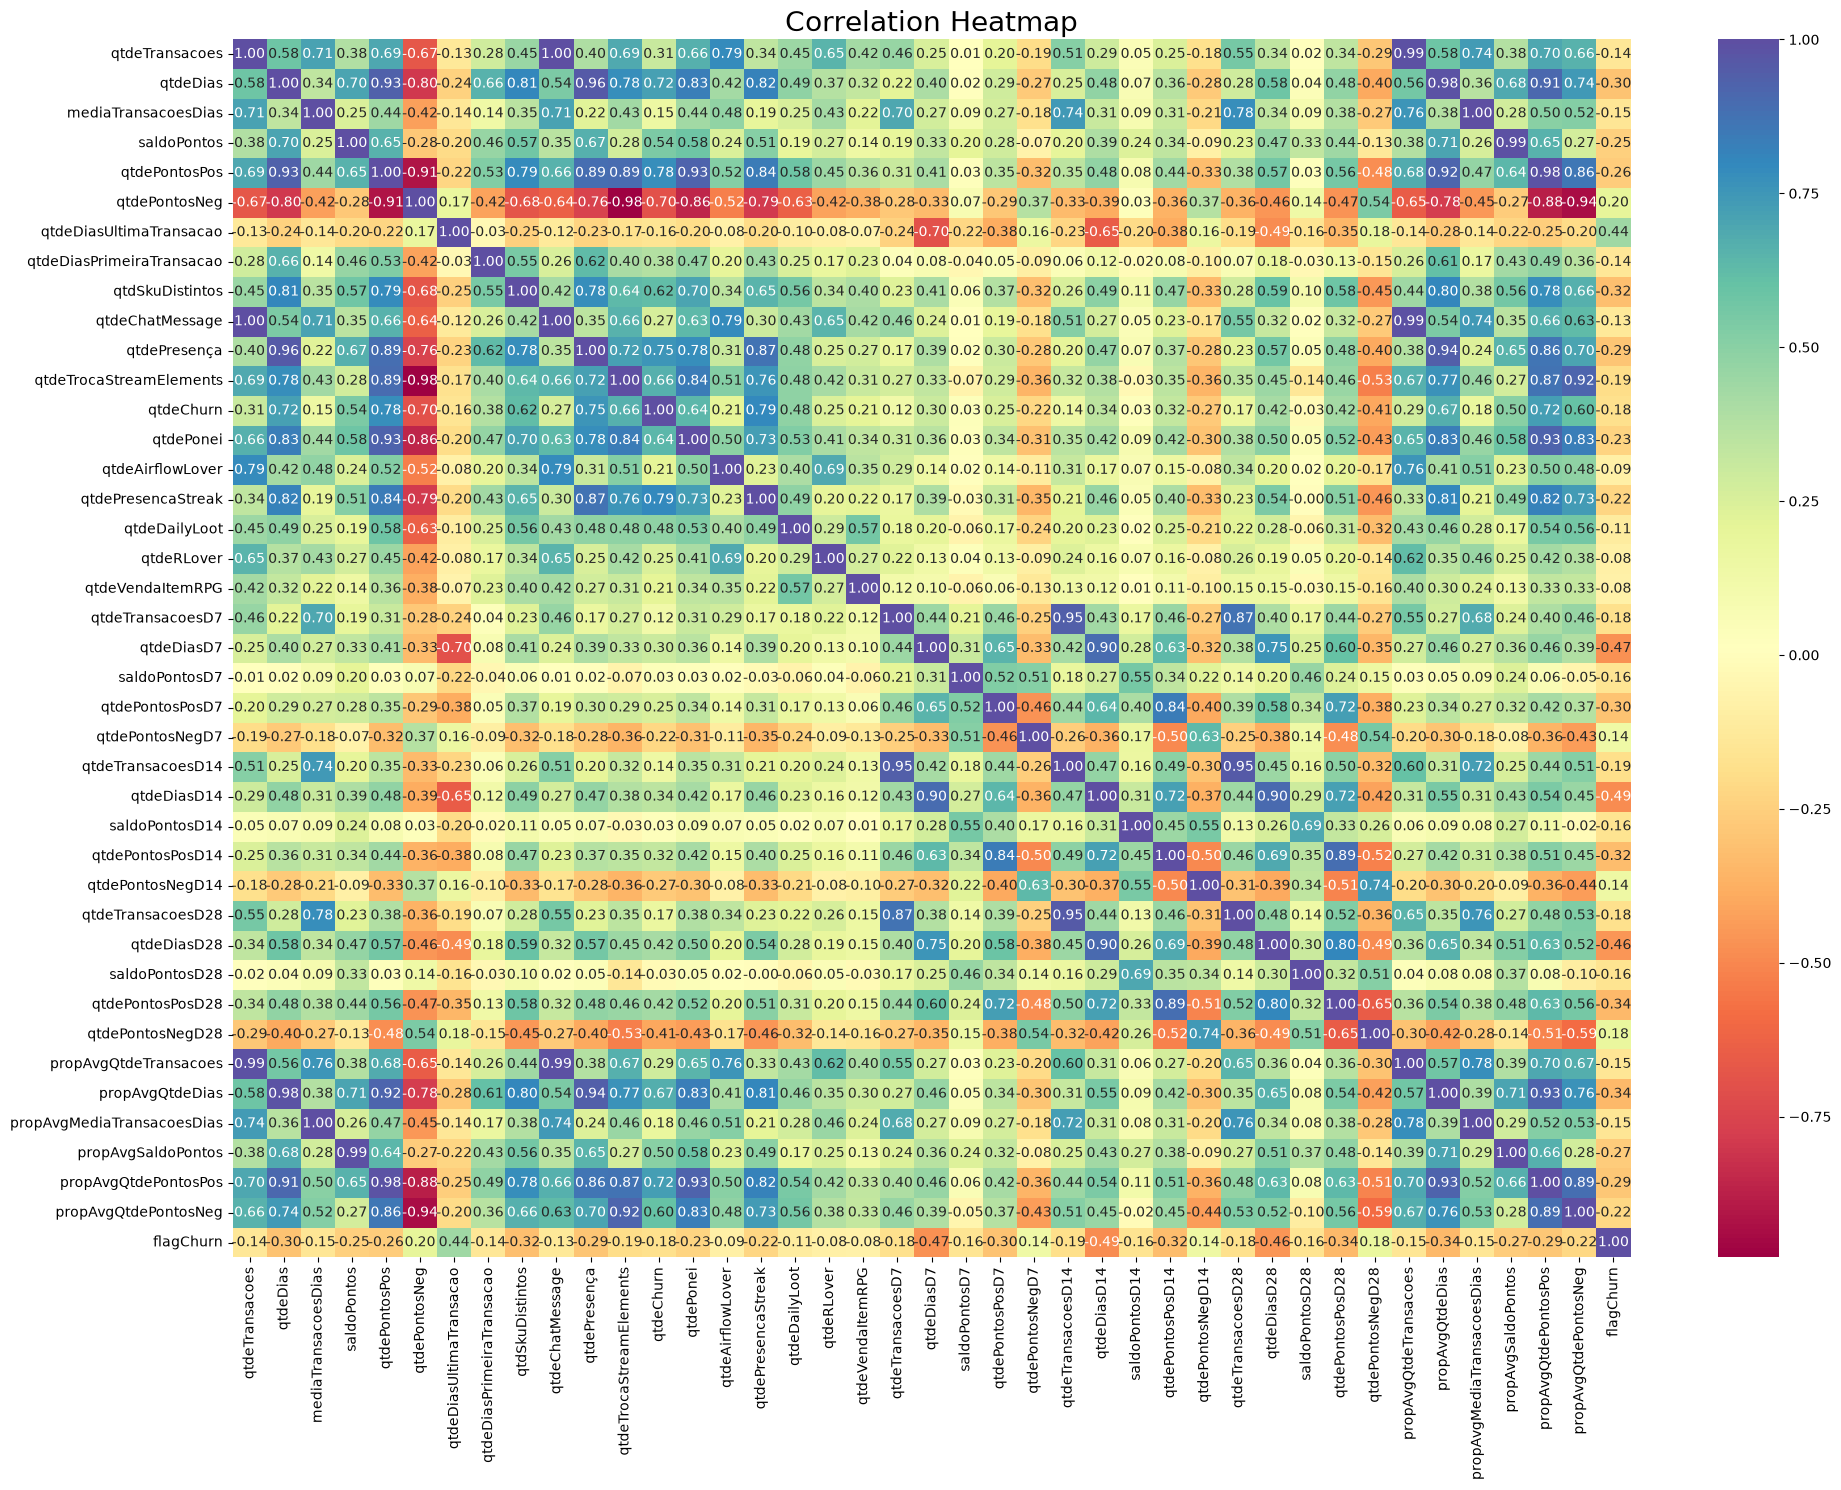

In [14]:
numeric_df = df_original.select_dtypes(include=np.number)

plt.figure(figsize=(20, 15))
corr = numeric_df.corr()
sns.heatmap(corr, annot=True, cmap="Spectral", fmt=".2f")
plt.title("Correlation Heatmap", fontsize=20)
plt.show()


## 4. Preparação para modelagem

### Checagem automática de possível vazamento (leakage)

Para toda coluna numérica que **não** está em `CONFIG["leakage_columns"]`, calculamos a
correlação com o target. Colunas com correlação acima de
`CONFIG["leakage_corr_threshold"]` são sinalizadas como suspeitas — o nome pode indicar
uma variável calculada com dados posteriores ao período de referência, ou um proxy direto
do próprio evento que está sendo previsto. Vale investigar antes de confiar no modelo.

In [15]:
target_column = CONFIG["target_column"]

print("="*70)
print("TARGET COLUMN")
print("="*70)
print(target_column)
print("\nTarget Value Counts")
print(df_original[target_column].value_counts())

print("\n" + "="*70)
print("CHECAGEM AUTOMATICA DE VAZAMENTO")
print("="*70)

candidatas = [
    c for c in df_original.select_dtypes(include=np.number).columns
    if c not in CONFIG["leakage_columns"] and c != target_column
]

suspeitas = []
for c in candidatas:
    corr_val = df_original[[c, target_column]].corr().iloc[0, 1]
    if abs(corr_val) >= CONFIG["leakage_corr_threshold"]:
        suspeitas.append((c, corr_val))

if suspeitas:
    print(f"Colunas fora de leakage_columns com |correlacao| >= {CONFIG['leakage_corr_threshold']} com o target:")
    for c, v in sorted(suspeitas, key=lambda x: -abs(x[1])):
        print(f"  - {c}: {v:.4f}")
    print("\nAvalie se alguma dessas colunas deveria entrar em CONFIG[\"leakage_columns\"].")
else:
    print("Nenhuma coluna suspeita encontrada acima do limiar configurado.")


TARGET COLUMN
target

Target Value Counts


KeyError: 'target'

In [ ]:
# ============================================================
# FEATURES (X) E TARGET (y)
# ============================================================

cols_a_remover = list(CONFIG["leakage_columns"])
if CONFIG["id_column"] and CONFIG["id_column"] not in cols_a_remover:
    cols_a_remover.append(CONFIG["id_column"])

X = df_original.drop(columns=[c for c in cols_a_remover if c in df_original.columns])
y = df_original[target_column]

# Garante que o target nao sobrou em X por engano
if target_column in X.columns:
    X = X.drop(columns=[target_column])

print("X shape:", X.shape)
print("y shape:", y.shape)


In [ ]:
# ============================================================
# IDENTIFICAR COLUNAS CATEGORICAS E NUMERICAS
# ============================================================

categorical_columns = X.select_dtypes(include=["object", "category"]).columns.tolist()
numerical_columns = X.select_dtypes(include=np.number).columns.tolist()

print("="*70)
print("CATEGORICAL COLUMNS")
print("="*70)
print(categorical_columns, len(categorical_columns))

print("\n" + "="*70)
print("NUMERICAL COLUMNS")
print("="*70)
print(numerical_columns, len(numerical_columns))


### Train/test split

Se `CONFIG["time_column"]` estiver definido, o split é **temporal**: os períodos mais
recentes (proporcionais a `CONFIG["test_size"]`) vão para teste, e o restante para
treino — isso evita vazamento temporal em problemas com componente de tempo (ex.: churn
mês a mês). Caso contrário, usa um `train_test_split` aleatório estratificado pelo
target.

In [ ]:
# ============================================================
# TRAIN/TEST SPLIT (temporal ou aleatorio, conforme CONFIG)
# ============================================================

if CONFIG["time_column"]:
    time_col = CONFIG["time_column"]
    datas_ordenadas = sorted(df_original[time_col].unique())
    n_periodos_teste = max(1, round(len(datas_ordenadas) * CONFIG["test_size"]))
    corte = datas_ordenadas[-n_periodos_teste]

    mask_teste = df_original[time_col] >= corte
    mask_treino = ~mask_teste

    X_train, X_test = X[mask_treino], X[mask_teste]
    y_train, y_test = y[mask_treino], y[mask_teste]

    print("="*70)
    print("TIME-BASED TRAIN/TEST SPLIT")
    print("="*70)
    print(f"Periodos de treino ({len(datas_ordenadas) - n_periodos_teste}): {datas_ordenadas[:-n_periodos_teste]}")
    print(f"Periodos de teste  ({n_periodos_teste}): {datas_ordenadas[-n_periodos_teste:]}")
else:
    X_train, X_test, y_train, y_test = train_test_split(
        X, y,
        test_size=CONFIG["test_size"],
        random_state=CONFIG["random_state"],
        stratify=y,
    )
    print("="*70)
    print("RANDOM TRAIN/TEST SPLIT (estratificado pelo target)")
    print("="*70)

print("\nX_train shape:", X_train.shape)
print("X_test shape :", X_test.shape)

print("\nDistribuicao do target no treino:")
print(y_train.value_counts(normalize=True))
print("\nDistribuicao do target no teste:")
print(y_test.value_counts(normalize=True))


## 5. Pipelines de pré-processamento

In [ ]:
# ============================================================
# PREPROCESSING PIPELINES
# ============================================================

numerical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore")),
])

preprocessor = ColumnTransformer(transformers=[
    ("num", numerical_transformer, numerical_columns),
    ("cat", categorical_transformer, categorical_columns),
])


## 6. Treinamento dos modelos

Edite o dicionário `MODELS` para trocar/adicionar modelos. `USE_PCA` controla se cada
modelo usa PCA no pipeline — **modelos de árvore não devem usar PCA**, pois isso
destrói a interpretabilidade por feature original (necessária para o SHAP na seção 7).
O modelo apontado por `CONFIG["shap_tree_model"]` precisa ter `USE_PCA[...] = False`, e
o apontado por `CONFIG["ame_logit_model"]` precisa ser uma Regressão Logística.

In [ ]:
# ============================================================
# USE_PCA: True para modelos baseados em distancia/lineares
# (Logistic Regression, Naive Bayes, KNN, SVM); False para modelos de
# arvore (Decision Tree, Random Forest, Gradient Boosting), que nao se
# beneficiam do PCA e perderiam a interpretabilidade nativa por feature.
# ============================================================

USE_PCA = {
    "Logistic Regression": True,
    "Naive Bayes": True,
    "Decision Tree": False,
    "Random Forest": False,
    "Gradient Boosting": False,
    "KNN": True,
    "SVM": True,
}

MODELS = {
    "Logistic Regression": LogisticRegression(max_iter=5000),
    "Naive Bayes": GaussianNB(),
    "Decision Tree": DecisionTreeClassifier(random_state=CONFIG["random_state"]),
    "Random Forest": RandomForestClassifier(n_estimators=200, random_state=CONFIG["random_state"]),
    "Gradient Boosting": GradientBoostingClassifier(random_state=CONFIG["random_state"]),
    "KNN": KNeighborsClassifier(),
    "SVM": SVC(probability=True, random_state=CONFIG["random_state"]),
}

assert CONFIG["shap_tree_model"] in MODELS, "CONFIG['shap_tree_model'] precisa estar em MODELS"
assert not USE_PCA.get(CONFIG["shap_tree_model"], True), "O modelo usado no SHAP nao pode usar PCA"
assert CONFIG["ame_logit_model"] in MODELS, "CONFIG['ame_logit_model'] precisa estar em MODELS"


In [ ]:
# ============================================================
# TRAIN & EVALUATE MODELS
# ============================================================

results = []
fitted_pipelines = {}  # guarda os pipelines treinados para reaproveitar depois

for model_name, model in MODELS.items():

    print("\n" + "="*80)
    print(model_name.upper())
    print("="*80)

    steps = [("preprocessor", preprocessor)]
    if USE_PCA.get(model_name, True):
        steps.append(("pca", PCA(n_components=0.95, random_state=CONFIG["random_state"])))
    steps.append(("model", model))

    pipeline = Pipeline(steps=steps)

    scores = cross_val_score(pipeline, X_train, y_train, cv=10)
    print(f"\nCross-Validation Scores : [{', '.join(f'{s:.4f}' for s in scores)}]")
    print(f"Media                   : {scores.mean():.4f}")
    print(f"Desvio padrao           : {scores.std():.4f}")

    pipeline.fit(X_train, y_train)
    fitted_pipelines[model_name] = pipeline

    y_pred = pipeline.predict(X_test)
    y_prob = pipeline.predict_proba(X_test)

    accuracy = accuracy_score(y_test, y_pred)
    print(f"\nAccuracy Score : {accuracy:.4f}")

    print("\nCLASSIFICATION REPORT")
    print("-"*60)
    print(classification_report(y_test, y_pred))

    cm = confusion_matrix(y_test, y_pred)
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
    plt.title(f"Confusion Matrix - {model_name}")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()

    if len(np.unique(y)) == 2:
        auc_score = roc_auc_score(y_test, y_prob[:, 1])
        fpr, tpr, _ = roc_curve(y_test, y_prob[:, 1])

        plt.figure(figsize=(8, 6))
        plt.plot(fpr, tpr, linewidth=3, label=f"AUC = {auc_score:.4f}")
        plt.plot([0, 1], [0, 1], linestyle="--")
        plt.xlabel("False Positive Rate")
        plt.ylabel("True Positive Rate")
        plt.title(f"ROC Curve - {model_name}")
        plt.legend()
        plt.show()
    else:
        auc_score = roc_auc_score(y_test, y_prob, multi_class="ovr")
        print(f"\nMulti-Class ROC AUC Score : {auc_score:.4f}")

    results.append({"Model": model_name, "Accuracy": accuracy, "ROC_AUC": auc_score})

results_df = pd.DataFrame(results)

print("\n" + "="*80)
print("FINAL MODEL COMPARISON")
print("="*80)
print(results_df.sort_values(by="Accuracy", ascending=False))

plt.figure(figsize=(12, 6))
sns.barplot(x="Accuracy", y="Model", data=results_df.sort_values(by="Accuracy", ascending=False),
            hue="Model", legend=False, palette="viridis")
plt.title("Model Accuracy Comparison", fontsize=18)
plt.show()

plt.figure(figsize=(12, 6))
sns.barplot(x="ROC_AUC", y="Model", data=results_df.sort_values(by="ROC_AUC", ascending=False),
            hue="Model", legend=False, palette="magma")
plt.title("ROC AUC Score Comparison", fontsize=18)
plt.show()

best_model = results_df.sort_values(by="Accuracy", ascending=False).iloc[0]
print("\n" + "="*80)
print("BEST MODEL")
print("="*80)
print(f"Best Model      : {best_model['Model']}")
print(f"Best Accuracy   : {best_model['Accuracy']:.4f}")
print(f"Best ROC AUC    : {best_model['ROC_AUC']:.4f}")


### Feature importance nativa (modelo de árvore usado no SHAP)

Usa a importância por impureza (Gini/MSE) do modelo apontado em
`CONFIG["shap_tree_model"]`. Esse ranking tende a favorecer variáveis numéricas
contínuas e de alta cardinalidade — por isso é combinado com SHAP e AME nas próximas
seções, em vez de usado isoladamente.

In [ ]:
tree_model_name = CONFIG["shap_tree_model"]
tree_pipeline = fitted_pipelines[tree_model_name]

all_features = tree_pipeline.named_steps["preprocessor"].get_feature_names_out()
importances = tree_pipeline.named_steps["model"].feature_importances_

feature_importance_df = pd.DataFrame({
    "Feature": all_features,
    "Importance": importances,
}).sort_values(by="Importance", ascending=False).reset_index(drop=True)

print("="*80)
print(f"FEATURE IMPORTANCE (IMPUREZA) - {tree_model_name.upper()}")
print("="*80)
print(feature_importance_df.head(CONFIG["top_n_features"]))

plot_df = feature_importance_df.head(CONFIG["top_n_features"])
plt.figure(figsize=(14, 8))
sns.barplot(x="Importance", y="Feature", data=plot_df, hue="Feature", legend=False, palette="coolwarm")
plt.title(f"Top {CONFIG['top_n_features']} Features por Importancia (Impureza) - {tree_model_name}", fontsize=16)
plt.show()


## 7. Interpretabilidade: SHAP (modelo de árvore)

SHAP (SHapley Additive exPlanations) atribui a cada feature uma contribuição para a
predição de cada observação, com base na teoria dos jogos. Aqui usamos
`TreeExplainer`, aplicado ao modelo de árvore configurado em
`CONFIG["shap_tree_model"]` — que **não** passa por PCA, permitindo atribuir
importância diretamente às features de negócio originais.

In [ ]:
# Descomente para instalar, se necessario
# import sys
# !{sys.executable} -m pip install shap

import shap
shap.initjs()


In [ ]:
# ============================================================
# SHAP - CALCULO DOS VALORES
# ============================================================

shap_pipeline = fitted_pipelines[CONFIG["shap_tree_model"]]
shap_preprocessor = shap_pipeline.named_steps["preprocessor"]
shap_model = shap_pipeline.named_steps["model"]

feature_names_shap = shap_preprocessor.get_feature_names_out()

X_test_transformed = shap_preprocessor.transform(X_test)
# get_feature_names_out ja lida com output esparso/denso da maioria dos ColumnTransformer;
# convertendo para array denso caso a transformacao retorne matriz esparsa (ex.: OneHotEncoder)
if hasattr(X_test_transformed, "toarray"):
    X_test_transformed = X_test_transformed.toarray()

X_test_shap_df = pd.DataFrame(X_test_transformed, columns=feature_names_shap, index=X_test.index)

explainer = shap.TreeExplainer(shap_model)
shap_values = explainer.shap_values(X_test_shap_df)

# Dependendo da versao do shap e do tipo de modelo, o retorno pode ser:
# - um array (n_samples, n_features) -> classificador binario, ja e a classe positiva
# - uma lista [shap_classe_0, shap_classe_1] -> pega a classe positiva (indice 1)
# - um array (n_samples, n_features, n_classes) -> pega a classe positiva (indice 1)
if isinstance(shap_values, list):
    shap_values_pos = shap_values[1]
else:
    shap_values_pos = shap_values
    if np.ndim(shap_values_pos) == 3:
        shap_values_pos = shap_values_pos[:, :, 1]

print("Shape dos valores SHAP:", np.array(shap_values_pos).shape)


In [ ]:
# ============================================================
# SHAP - GRAFICOS
# ============================================================

plt.figure(figsize=(12, 8))
shap.summary_plot(shap_values_pos, X_test_shap_df, plot_type="bar", show=False)
plt.title(f"SHAP - Importancia Media |SHAP value| - {CONFIG['shap_tree_model']}", fontsize=16)
plt.tight_layout()
plt.show()

plt.figure(figsize=(12, 8))
shap.summary_plot(shap_values_pos, X_test_shap_df, show=False)
plt.title(f"SHAP - Distribuicao dos Impactos por Feature - {CONFIG['shap_tree_model']}", fontsize=16)
plt.tight_layout()
plt.show()


In [ ]:
# ============================================================
# SHAP - RANKING E DEPENDENCE PLOT DA FEATURE MAIS IMPORTANTE
# ============================================================

shap_importance_df = pd.DataFrame({
    "Feature": feature_names_shap,
    "Mean|SHAP|": np.abs(shap_values_pos).mean(axis=0),
}).sort_values(by="Mean|SHAP|", ascending=False).reset_index(drop=True)

print("="*80)
print(f"TOP {CONFIG['top_n_features']} FEATURES POR SHAP - {CONFIG['shap_tree_model'].upper()}")
print("="*80)
print(shap_importance_df.head(CONFIG["top_n_features"]).to_string(index=False))

top_feature_shap = shap_importance_df.iloc[0]["Feature"]

plt.figure(figsize=(10, 6))
shap.dependence_plot(top_feature_shap, shap_values_pos, X_test_shap_df, show=False)
plt.title(f"SHAP Dependence Plot - {top_feature_shap} ({CONFIG['shap_tree_model']})", fontsize=14)
plt.tight_layout()
plt.show()


## 8. Interpretabilidade: AME (Average Marginal Effects) — Regressão Logística

O AME mede o efeito médio de cada variável sobre a probabilidade prevista pelo modelo.
Se `CONFIG["ame_logit_model"]` usa PCA no pipeline (`USE_PCA[...] = True`), os
componentes principais não são interpretáveis em nível de feature original — por isso
ajustamos aqui um **Logit equivalente sem PCA** (mesmo pré-processamento de imputação +
padronização/one-hot), apenas para fins de interpretação. O modelo original
(`fitted_pipelines[CONFIG["ame_logit_model"]]`) continua sendo o utilizado para
decisão/predição em produção.

In [ ]:
# ============================================================
# AME - PREPROCESSAMENTO SEM PCA (mantem as features originais interpretaveis)
# ============================================================
import statsmodels.api as sm

# Clone do preprocessador original para nao interferir nos pipelines ja treinados
preprocessor_ame = clone(preprocessor)

X_train_ame = preprocessor_ame.fit_transform(X_train, y_train)
X_test_ame = preprocessor_ame.transform(X_test)

if hasattr(X_train_ame, "toarray"):
    X_train_ame = X_train_ame.toarray()
if hasattr(X_test_ame, "toarray"):
    X_test_ame = X_test_ame.toarray()

feature_names_ame = preprocessor_ame.get_feature_names_out()

X_train_ame_df = pd.DataFrame(X_train_ame, columns=feature_names_ame, index=X_train.index).astype(float)
X_test_ame_df = pd.DataFrame(X_test_ame, columns=feature_names_ame, index=X_test.index).astype(float)

X_train_ame_sm = sm.add_constant(X_train_ame_df)

print("Shape usado no Logit (statsmodels):", X_train_ame_sm.shape)


In [ ]:
# ============================================================
# AME - AJUSTE DO MODELO LOGIT (statsmodels)
# ============================================================
# Com muitas variaveis (possivelmente correlacionadas, como visto no mapa de calor),
# a maxima verossimilhanca pode nao convergir bem. Se isso acontecer, caimos para
# uma versao regularizada (L1) do Logit.

try:
    logit_result = sm.Logit(y_train.values, X_train_ame_sm).fit(disp=0, maxiter=200)
    ame_method = "MLE (sm.Logit.fit)"
    tem_cov_params = True
except Exception as e:
    print(f"MLE nao convergiu ({e}). Usando regularizacao L1 (fit_regularized).")
    logit_result = sm.Logit(y_train.values, X_train_ame_sm).fit_regularized(alpha=1.0, disp=0)
    ame_method = "Regularizado L1 (fit_regularized)"
    tem_cov_params = False

print(f"\nMetodo utilizado: {ame_method}")
print(logit_result.summary())


In [ ]:
# ============================================================
# AME - CALCULO DOS EFEITOS MARGINAIS MEDIOS
# ============================================================

try:
    if not tem_cov_params:
        raise RuntimeError("Modelo regularizado nao tem matriz de covariancia -> get_margeff indisponivel")
    margeff = logit_result.get_margeff(at="overall", method="dydx")
    ame_df = pd.DataFrame({
        "Feature": X_train_ame_sm.columns[1:],
        "AME": margeff.margeff,
        "Std Err": margeff.margeff_se,
        "p-value": margeff.pvalues,
    })
except Exception as e:
    print(f"get_margeff indisponivel ({e}). Calculando AME por diferenca finita (dy/dx numerico).")
    eps = 1e-4
    base_probs = logit_result.predict(X_train_ame_sm)
    ame_list = []
    for col in X_train_ame_df.columns:
        X_plus = X_train_ame_sm.copy()
        X_plus[col] = X_plus[col] + eps
        probs_plus = logit_result.predict(X_plus)
        ame_list.append((probs_plus - base_probs).mean() / eps)
    ame_df = pd.DataFrame({"Feature": X_train_ame_df.columns, "AME": ame_list})

ame_df["AME_abs"] = ame_df["AME"].abs()
ame_df = ame_df.sort_values(by="AME_abs", ascending=False).reset_index(drop=True)

print("="*80)
print(f"TOP {CONFIG['top_n_features']} FEATURES POR AME (efeito medio na probabilidade PREVISTA)")
print("="*80)
print(ame_df.head(CONFIG["top_n_features"]).to_string(index=False))


In [ ]:
# ============================================================
# AME - GRAFICO
# ============================================================

top_ame = ame_df.head(CONFIG["top_n_features"]).sort_values(by="AME")
cores = ["#d62728" if v > 0 else "#1f77b4" for v in top_ame["AME"]]

plt.figure(figsize=(12, 8))
plt.barh(top_ame["Feature"], top_ame["AME"], color=cores)
plt.axvline(0, color="black", linewidth=0.8)
plt.title(f"Top {CONFIG['top_n_features']} Features - Average Marginal Effect (AME)", fontsize=16)
plt.xlabel("Efeito medio na probabilidade prevista", fontsize=12)
plt.tight_layout()
plt.show()

print("Interpretacao:")
print("- Barras vermelhas (AME > 0): aumento na variavel aumenta, em media, a probabilidade prevista.")
print("- Barras azuis  (AME < 0): aumento na variavel reduz, em media, a probabilidade prevista.")


## 9. Síntese — Ranking consolidado (Importância nativa + SHAP + AME)

In [ ]:
# ============================================================
# RANKING CONSOLIDADO - COMPARANDO OS METODOS DISPONIVEIS
# ============================================================
# Cada metodo enxerga "importancia" de um jeito diferente (impureza no split,
# contribuicao Shapley para a predicao, efeito marginal na probabilidade). Se uma
# mesma variavel aparece no topo em todos, isso e evidencia forte de que ela e, de
# fato, um direcionador real do target -- e nao apenas um artefato de um metodo
# ou modelo especifico.

def normalizar_nome(feat):
    return feat.replace("num__", "").replace("cat__", "")

rf_rank = feature_importance_df.copy()
rf_rank["Feature_norm"] = rf_rank["Feature"].apply(normalizar_nome)
rf_rank["Rank_Importancia_Nativa"] = rf_rank["Importance"].rank(ascending=False)

shap_rank = shap_importance_df.copy()
shap_rank["Feature_norm"] = shap_rank["Feature"].apply(normalizar_nome)
shap_rank["Rank_SHAP"] = shap_rank["Mean|SHAP|"].rank(ascending=False)

ame_rank = ame_df.copy()
ame_rank["Feature_norm"] = ame_rank["Feature"].apply(normalizar_nome)
ame_rank["Rank_AME"] = ame_rank["AME_abs"].rank(ascending=False)

consolidado = (
    rf_rank[["Feature_norm", "Rank_Importancia_Nativa"]]
    .merge(shap_rank[["Feature_norm", "Rank_SHAP"]], on="Feature_norm", how="outer")
    .merge(ame_rank[["Feature_norm", "Rank_AME"]], on="Feature_norm", how="outer")
)

consolidado["Rank_Medio"] = consolidado[
    ["Rank_Importancia_Nativa", "Rank_SHAP", "Rank_AME"]
].mean(axis=1)

consolidado = consolidado.sort_values(by="Rank_Medio").reset_index(drop=True)

print("="*80)
print(f"RANKING CONSOLIDADO DE IMPORTANCIA - TOP {CONFIG['top_n_features']}")
print("="*80)
print(consolidado.head(CONFIG["top_n_features"]).to_string(index=False))

feature_mais_importante = consolidado.iloc[0]["Feature_norm"]
print("\n" + "="*80)
print(f">>> VARIAVEL MAIS IMPORTANTE (consenso Importancia Nativa + SHAP + AME): {feature_mais_importante}")
print("="*80)


### Leitura dos resultados e cuidados antes de decidir

- **Convergência dos métodos**: se a mesma variável aparecer no topo de
  `Rank_Importancia_Nativa`, `Rank_SHAP` e `Rank_AME`, é um sinal forte de que ela
  realmente é um direcionador relevante do target — não um artefato de um único
  modelo. Se os métodos discordarem muito, vale investigar se algum modelo está
  capturando um padrão espúrio (ou colinearidade, como sinalizado no mapa de calor de
  correlação).
- **Checagem de vazamento**: antes de tomar a variável do topo do ranking como *a*
  resposta de negócio, confirme que ela não é um proxy do próprio evento que está
  sendo previsto (ver checagem automática na seção 4). Uma variável pode fazer sentido
  causal (ex.: tempo desde a última interação), mas vale sempre essa checagem para
  qualquer variável que assumir o topo.
- **SHAP explica o modelo, não a realidade**: os valores SHAP mostram o que o modelo de
  árvore aprendeu como relevante — é uma leitura de como o modelo decide, não uma prova
  de causalidade sobre o fenômeno real.
- **AME assume uma forma funcional (logit linear nos preditores)**: o efeito marginal
  médio da Regressão Logística pressupõe que a relação entre cada variável e o
  log-odds do target é aproximadamente linear (após padronização). Se essa relação for
  muito não-linear, o AME pode subestimar a importância real da variável — por isso ele
  é usado aqui em conjunto com o SHAP (que captura não-linearidades), e não
  isoladamente.